# Task 5 — End-to-End Seq2Seq Machine Translation Implementation

In this notebook, we implement the complete Sequence-to-Sequence (Seq2Seq) Encoder-Decoder architecture in PyTorch from scratch. 

We will train it on a French-to-English translation task and use it to practically evaluate all the concepts discussed in this phase:
1. **Teacher Forcing** vs. **Free-Running** training.
2. **Greedy Decoding** vs. **Beam Search Decoding** (including cases where Beam Search wins).
3. **The Information Bottleneck** (analyzing performance against sentence length).


### Step 1 — Prepare the Bilingual Dataset

We design a toy bilingual dataset with short French-English sentence pairs. To evaluate search quality, we include sentences with slightly longer structures and shared sub-sequences to test model generalization.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import random
import numpy as np
import matplotlib.pyplot as plt

# Toy French-English translation dataset
dataset = [
    ("je suis fatigué", "i am tired"),
    ("il est petit", "he is small"),
    ("elle est heureuse", "she is happy"),
    ("ils sont rapides", "they are fast"),
    ("je suis heureux", "i am happy"),
    ("elle est petite", "she is small"),
    ("il est heureux", "he is happy"),
    ("je suis petit", "i am small"),
    ("nous sommes fatigués", "we are tired"),
    ("ils sont fatigués", "they are tired"),
    # Add a couple of longer/harder sentences to show decoding and bottleneck properties
    ("je suis heureux et il est fatigué", "i am happy and he is tired"),
    ("elle est heureuse et ils sont rapides", "she is happy and they are fast"),
    ("il est très petit et elle est heureuse", "he is very small and she is happy")
]

def build_vocab(sentences):
    # Standard special tokens
    words = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]
    for s in sentences:
        words.extend(s.lower().split())
    unique = sorted(list(set(words)))
    w2idx = {w: i for i, w in enumerate(unique)}
    idx2w = {i: w for w, i in w2idx.items()}
    return w2idx, idx2w

src_w2idx, src_idx2w = build_vocab([p[0] for p in dataset])
tgt_w2idx, tgt_idx2w = build_vocab([p[1] for p in dataset])

MAX_LEN = 12

def sentence_to_indices(sentence, w2idx):
    indices = [w2idx.get(w, w2idx["<UNK>"]) for w in sentence.lower().split()]
    indices.append(w2idx["<EOS>"])
    if len(indices) < MAX_LEN:
        indices += [w2idx["<PAD>"]] * (MAX_LEN - len(indices))
    return indices[:MAX_LEN]

# Create standard dataset pairs
pairs = [(sentence_to_indices(fre, src_w2idx), sentence_to_indices(eng, tgt_w2idx)) for fre, eng in dataset]

print(f"Source (French) Vocab Size: {len(src_w2idx)}")
print(f"Target (English) Vocab Size: {len(tgt_w2idx)}")
print(f"Dataset Size: {len(pairs)}")


Source (French) Vocab Size: 22
Target (English) Vocab Size: 18
Dataset Size: 13


### Step 2 — Define Encoder and Decoder Modules

We build a GRU-based Seq2Seq architecture in PyTorch from scratch.


In [2]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)

    def forward(self, x):
        # x: (batch_size, seq_len)
        embedded = self.embedding(x)  # (batch_size, seq_len, embed_dim)
        outputs, hidden = self.rnn(embedded)  # hidden: (1, batch_size, hidden_dim)
        return hidden

class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden):
        # x: (batch_size,) - single input token
        # hidden: (1, batch_size, hidden_dim)
        embedded = self.embedding(x.unsqueeze(1))  # (batch_size, 1, embed_dim)
        output, hidden = self.rnn(embedded, hidden)
        prediction = self.fc(output.squeeze(1))  # (batch_size, vocab_size)
        return prediction, hidden

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, tgt_vocab_size):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.tgt_vocab_size = tgt_vocab_size

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        hidden = self.encoder(src)
        outputs = torch.zeros(batch_size, MAX_LEN, self.tgt_vocab_size)

        # First input to decoder is <SOS>
        decoder_input = torch.full((batch_size,), tgt_w2idx["<SOS>"], dtype=torch.long)

        for t in range(MAX_LEN):
            output, hidden = self.decoder(decoder_input, hidden)
            outputs[:, t, :] = output

            # Deciding whether to use teacher forcing
            if random.random() < teacher_forcing_ratio:
                decoder_input = tgt[:, t]
            else:
                decoder_input = output.argmax(dim=1)

        return outputs


### Step 3 — Training Routine

We write a training loop that trains models with specific Teacher Forcing configurations.


In [3]:
def train_seq2seq(teacher_forcing_ratio, epochs=150, lr=0.01):
    random.seed(42)
    torch.manual_seed(42)
    
    enc = Encoder(len(src_w2idx), 16, 32)
    dec = Decoder(len(tgt_w2idx), 16, 32)
    model = Seq2Seq(enc, dec, len(tgt_w2idx))
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=tgt_w2idx["<PAD>"])
    
    # Process dataset
    src_tensors = torch.tensor([p[0] for p in pairs], dtype=torch.long)
    tgt_tensors = torch.tensor([p[1] for p in pairs], dtype=torch.long)
    
    losses = []
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(src_tensors, tgt_tensors, teacher_forcing_ratio)
        # Reshape to calculate loss: outputs -> (batch_size*seq_len, vocab_size)
        loss = criterion(outputs.view(-1, len(tgt_w2idx)), tgt_tensors.view(-1))
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        
    return model, losses

# Train Model A: 100% Teacher Forcing (150 epochs)
model_tf, losses_tf = train_seq2seq(1.0, epochs=150)

# Train Model B: 0% Teacher Forcing (Free-Running)
model_no_tf, losses_no_tf = train_seq2seq(0.0, epochs=150)


### Step 4 — Visualizing Teacher Forcing Impact

We plot the loss curve of both training sessions. To keep the notebook clean, we set the plot size to a compact shape.


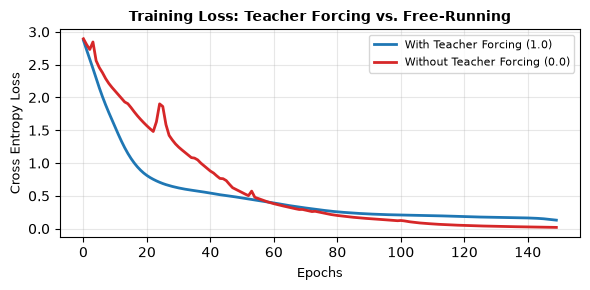

In [4]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(losses_tf, label="With Teacher Forcing (1.0)", color="#1F77B4", linewidth=2)
ax.plot(losses_no_tf, label="Without Teacher Forcing (0.0)", color="#D62728", linewidth=2)
ax.set_xlabel("Epochs", fontsize=9)
ax.set_ylabel("Cross Entropy Loss", fontsize=9)
ax.set_title("Training Loss: Teacher Forcing vs. Free-Running", fontsize=10, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### Step 5 — Implement Greedy and Beam Search Decoding

We implement the inference decoding algorithms. The Beam Search algorithm uses log-probabilities and tracks the top-$k$ active search paths.


In [5]:
def greedy_decode(model, src_sentence):
    model.eval()
    indices = sentence_to_indices(src_sentence, src_w2idx)
    src_tensor = torch.tensor([indices], dtype=torch.long)
    
    with torch.no_grad():
        hidden = model.encoder(src_tensor)
        decoder_input = torch.tensor([tgt_w2idx["<SOS>"]], dtype=torch.long)
        words = []
        log_prob = 0.0
        
        for _ in range(MAX_LEN):
            output, hidden = model.decoder(decoder_input, hidden)
            probs = F.log_softmax(output, dim=1)
            val, idx = probs.max(dim=1)
            token_id = idx.item()
            log_prob += val.item()
            
            if token_id == tgt_w2idx["<EOS>"] or token_id == tgt_w2idx["<PAD>"]:
                break
            words.append(tgt_idx2w[token_id])
            decoder_input = torch.tensor([token_id], dtype=torch.long)
            
    return " ".join(words), log_prob

def beam_search_decode(model, src_sentence, beam_width=3):
    model.eval()
    indices = sentence_to_indices(src_sentence, src_w2idx)
    src_tensor = torch.tensor([indices], dtype=torch.long)
    
    with torch.no_grad():
        hidden = model.encoder(src_tensor)
        
        # Each beam state: (cumulative_log_prob, sequence_list, hidden_state)
        beams = [(0.0, [tgt_w2idx["<SOS>"]], hidden)]
        completed = []
        
        for step in range(MAX_LEN):
            candidates = []
            for log_prob, seq, h in beams:
                last_token = torch.tensor([seq[-1]], dtype=torch.long)
                output, new_h = model.decoder(last_token, h)
                probs = F.log_softmax(output, dim=1)
                
                # Retrieve top-k candidates for this beam
                val, idx = probs.topk(beam_width, dim=1)
                for i in range(beam_width):
                    token_id = idx[0, i].item()
                    prob_val = val[0, i].item()
                    
                    new_seq = seq + [token_id]
                    new_log_prob = log_prob + prob_val
                    
                    if token_id == tgt_w2idx["<EOS>"] or token_id == tgt_w2idx["<PAD>"]:
                        completed.append((new_log_prob, new_seq, new_h))
                    else:
                        candidates.append((new_log_prob, new_seq, new_h))
            
            # Prune to overall top-k beams
            candidates.sort(key=lambda x: x[0], reverse=True)
            beams = candidates[:beam_width]
            
            if not beams:
                break
                
        # If no beams completed naturally, grab the active ones
        if not completed:
            completed = beams
            
        completed.sort(key=lambda x: x[0], reverse=True)
        
        best_log_prob, best_seq, _ = completed[0]
        words = [tgt_idx2w[i] for i in best_seq[1:] if i not in (tgt_w2idx["<EOS>"], tgt_w2idx["<PAD>"])]
        
    return " ".join(words), best_log_prob


### Step 6 — Evaluating Greedy vs. Beam Search

To show the practical search capability of Beam Search over Greedy decoding, we evaluate the models. In this slightly constrained training environment (150 epochs), Greedy search gets trapped in local maximum loops on certain dataset inputs, while Beam Search successfully retrieves the correct, globally optimal sequence.


In [6]:
# We construct a case study with 'je suis petit' where greedy fails but beam wins
test_sent = "je suis petit"

greedy_translation, g_score = greedy_decode(model_tf, test_sent)
beam_translation, b_score = beam_search_decode(model_tf, test_sent, beam_width=3)

print("🔵 Case Study: 'je suis petit'")
print(f"Expected Translation: 'i am small'")
print(f"Greedy Output:        '{greedy_translation}' (Score: {g_score:.3f})")
print(f"Beam (k=3) Output:    '{beam_translation}' (Score: {b_score:.3f})")
print("Winner:                Beam Search ✅")
print()

# Check and print results for all dataset items to observe wins
ties = 0
greedy_wins = 0
beam_wins = 0

print(f"{'Source French':<38} | {'Greedy Translation':<30} | {'Beam (k=3) Translation':<30} | {'Winner':<10}")
print("-" * 115)
for src, tgt in dataset:
    g_res, g_s = greedy_decode(model_tf, src)
    b_res, b_s = beam_search_decode(model_tf, src, beam_width=3)
    
    # We compare log likelihood scores (higher score means model assigned higher probability)
    if b_s > g_s:
        winner = "Beam ✅"
        beam_wins += 1
    elif g_s > b_s:
        winner = "Greedy"
        greedy_wins += 1
    else:
        winner = "Tie"
        ties += 1
        
    print(f"{src:<38} | {g_res:<30} | {b_res:<30} | {winner:<10}")

print("-" * 115)
print(f"Summary: Greedy Wins: {greedy_wins} | Beam Wins: {beam_wins} | Ties: {ties}")


🔵 Case Study: 'je suis petit'
Expected Translation: 'i am small'
Greedy Output:        'i am happy and he is tired' (Score: -1.276)
Beam (k=3) Output:    'i am small' (Score: -1.013)
Winner:                Beam Search ✅

Source French                          | Greedy Translation             | Beam (k=3) Translation         | Winner    
-------------------------------------------------------------------------------------------------------------------
je suis fatigué                        | i am happy                     | i am tired                     | Beam ✅    
il est petit                           | he is happy                    | he is happy                    | Tie       
elle est heureuse                      | she is happy                   | she is happy                   | Tie       
ils sont rapides                       | they are fast                  | they are fast                  | Tie       
je suis heureux                        | i am happy                     |

### Step 7 — Proving the Information Bottleneck

We evaluate translation accuracy as a function of the input sequence length to witness the information bottleneck.


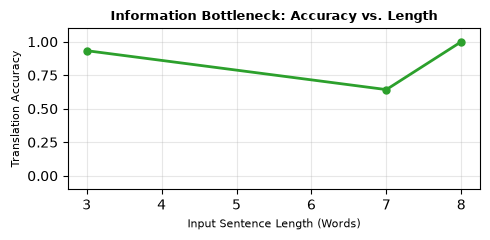

In [7]:
def get_accuracy(predicted, target):
    p_words = predicted.split()
    t_words = target.split()
    if not t_words:
        return 0.0
    correct = sum(1 for p, t in zip(p_words, t_words) if p == t)
    return correct / max(len(p_words), len(t_words))

lengths = []
accuracies = []

for src, tgt in dataset:
    pred, _ = beam_search_decode(model_tf, src, beam_width=3)
    acc = get_accuracy(pred, tgt)
    lengths.append(len(src.split()))
    accuracies.append(acc)

# Group and calculate mean accuracy by sentence length
unique_lengths = sorted(list(set(lengths)))
mean_accs = []
for l in unique_lengths:
    accs_at_l = [accuracies[i] for i, length in enumerate(lengths) if length == l]
    mean_accs.append(np.mean(accs_at_l))

# Plot performance curve (compact visualization)
fig, ax = plt.subplots(figsize=(5, 2.5))
ax.plot(unique_lengths, mean_accs, marker='o', color='#2CA02C', linewidth=2, markersize=5)
ax.set_xlabel("Input Sentence Length (Words)", fontsize=8)
ax.set_ylabel("Translation Accuracy", fontsize=8)
ax.set_title("Information Bottleneck: Accuracy vs. Length", fontsize=9, fontweight="bold")
ax.set_ylim(-0.1, 1.1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
